In [ ]:
import sys
import os

# Pfad anpassen, um utils_notebook importieren zu können
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

from utils_notebook.LR_utils_notebook.compare_LR import (
    compare_wunden_interactive,
    compare_categories_interactive
)

TWO_STAGE_RAW = "../../data/llm_outputs/two_stage_lr/two_stage_lr_raw.csv"
TWO_STAGE_NORM = "../../data/llm_outputs/two_stage_lr/two_stage_lr_normalised.csv"

# Interaktiver Vergleich pro Wunde und pro Kategorie mit den normalisierten LLM-Antworten
compare_wunden_interactive(normalised=True, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)
compare_categories_interactive(normalised=True, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)

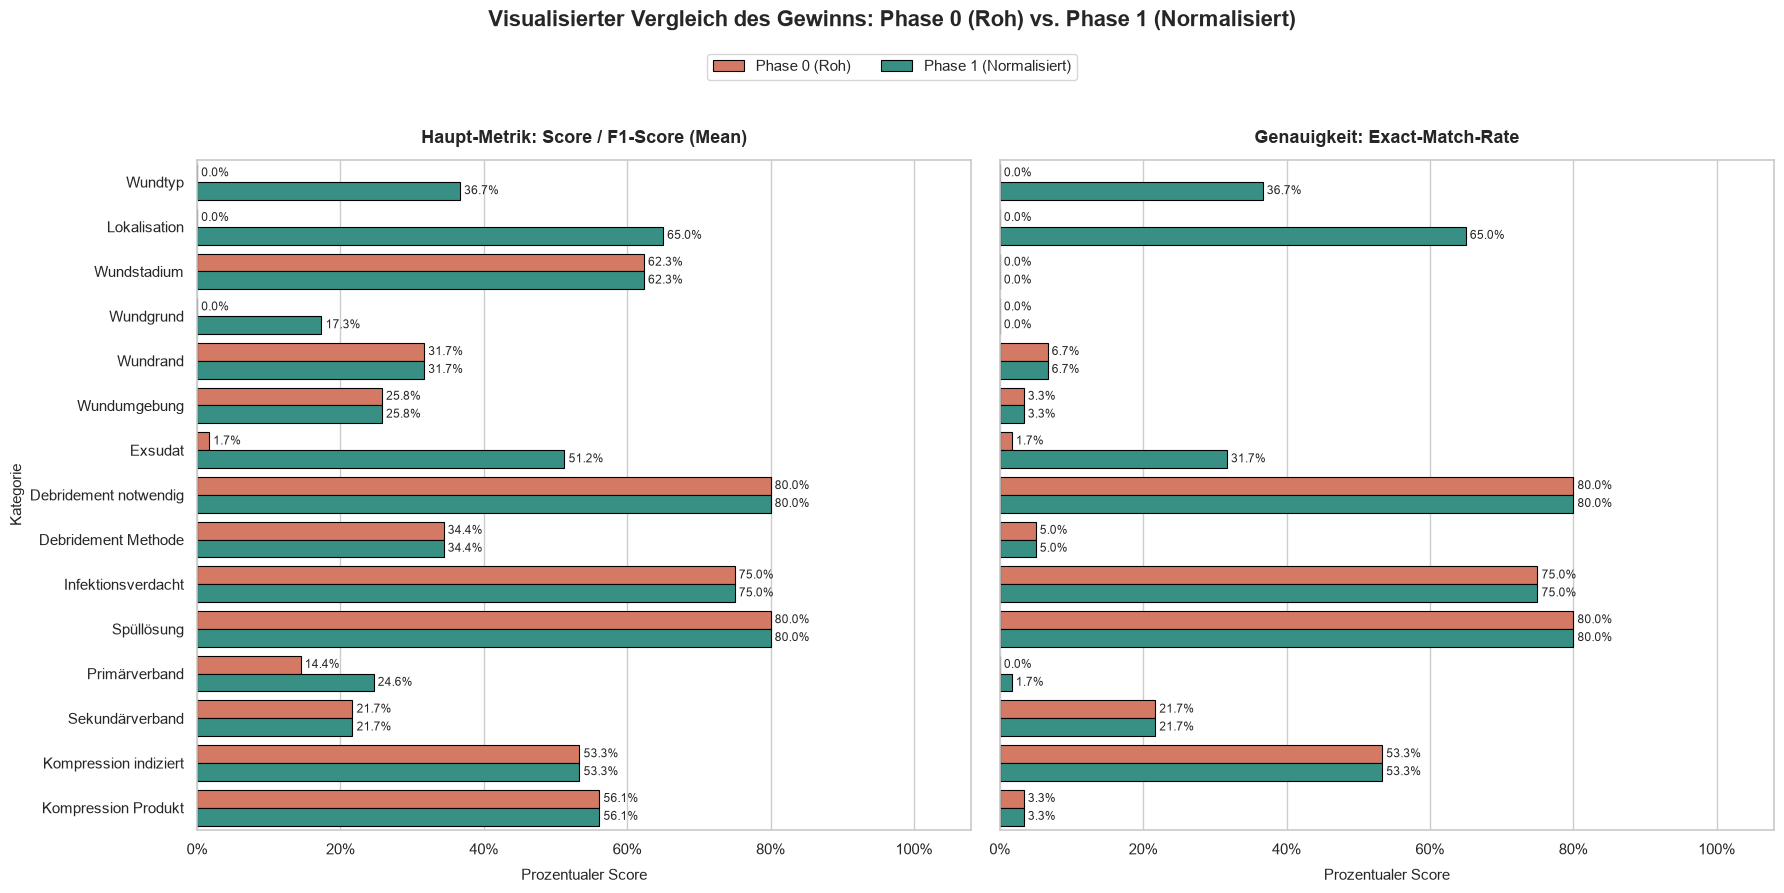

In [2]:
from utils_notebook.LR_utils_notebook.compare_LR import calculate_summary_LR
from utils_notebook.plot_compare import plot_gt_comparison

# 1. Summary-Scores für Phase 0 (Roh) und Phase 1 (Normalisiert) berechnen (im Vergleich zu Experte 1)
df_summary_raw = calculate_summary_LR(1, normalised=False, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)
df_summary_norm = calculate_summary_LR(1, normalised=True, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)

# 2. Zweigeteiltes Gruppiertes Balkendiagramm (Score / F1-Score & Exact-Match-Rate) rendern
plot_gt_comparison(df_summary_raw, df_summary_norm)

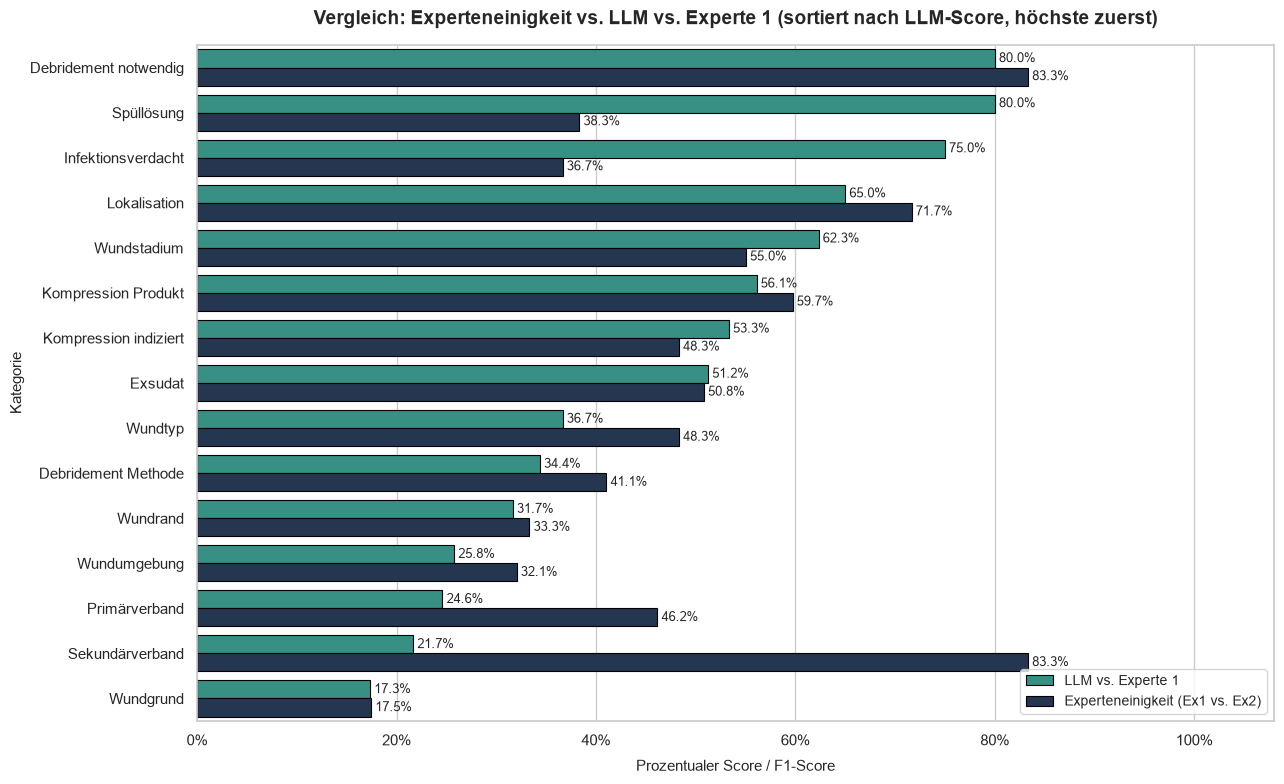

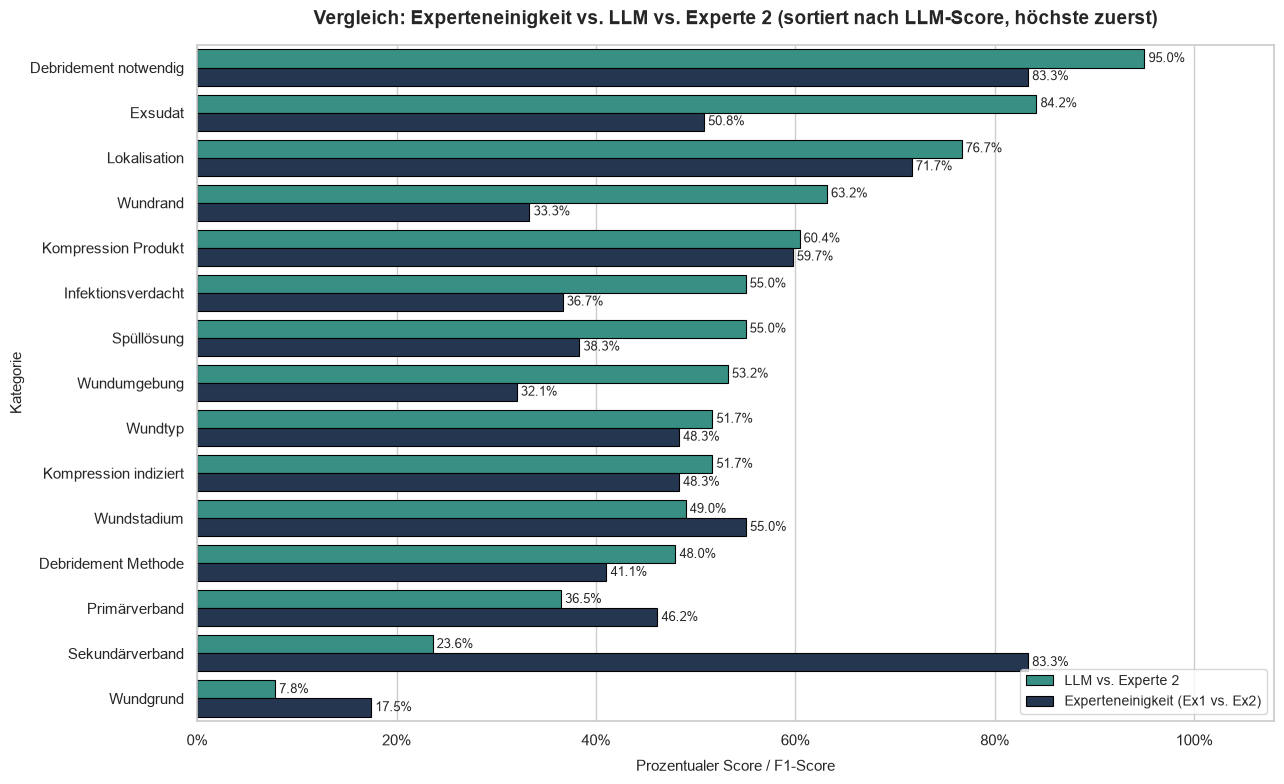

In [3]:
from utils_notebook.LR_utils_notebook.compare_LR import calculate_summary_LR, calculate_experts_summary_LR
from utils_notebook.plot_compare import plot_combined_single_chart

# 1. Experteneinigkeit (Ex1 vs. Ex2) für normalisierte Daten berechnen
df_experts_norm = calculate_experts_summary_LR(normalised=True)

# 2. Normalisierte LLM-Ergebnisse im Vergleich zu Experte 1 und Experte 2 berechnen
df_summary_norm_exp1 = calculate_summary_LR(1, normalised=True, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)
df_summary_norm_exp2 = calculate_summary_LR(2, normalised=True, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)

# 3. Plots zur Gegenüberstellung mit der Experteneinigkeit anzeigen
plot_combined_single_chart(df_experts_norm, df_summary_norm_exp1, expert_label="Experte 1")
plot_combined_single_chart(df_experts_norm, df_summary_norm_exp2, expert_label="Experte 2")

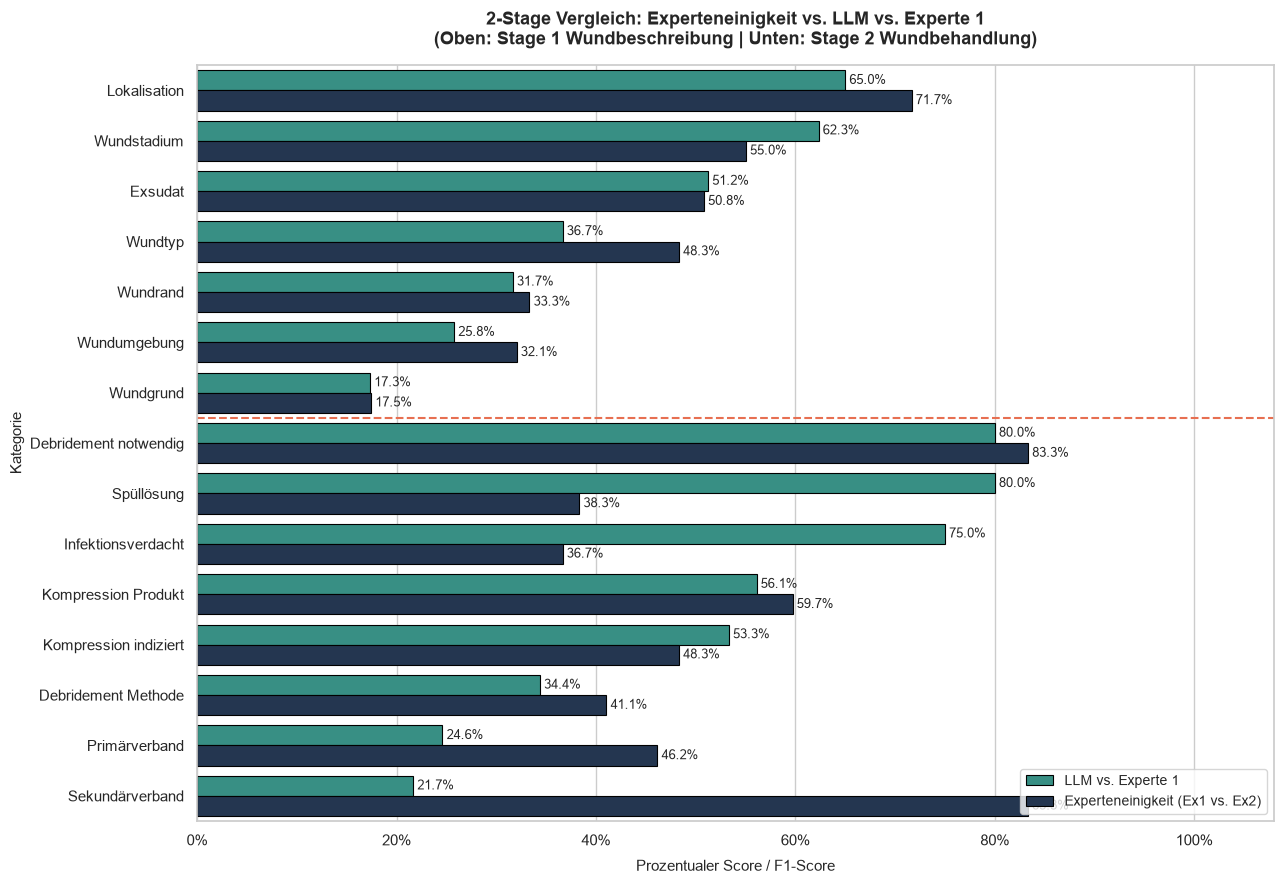

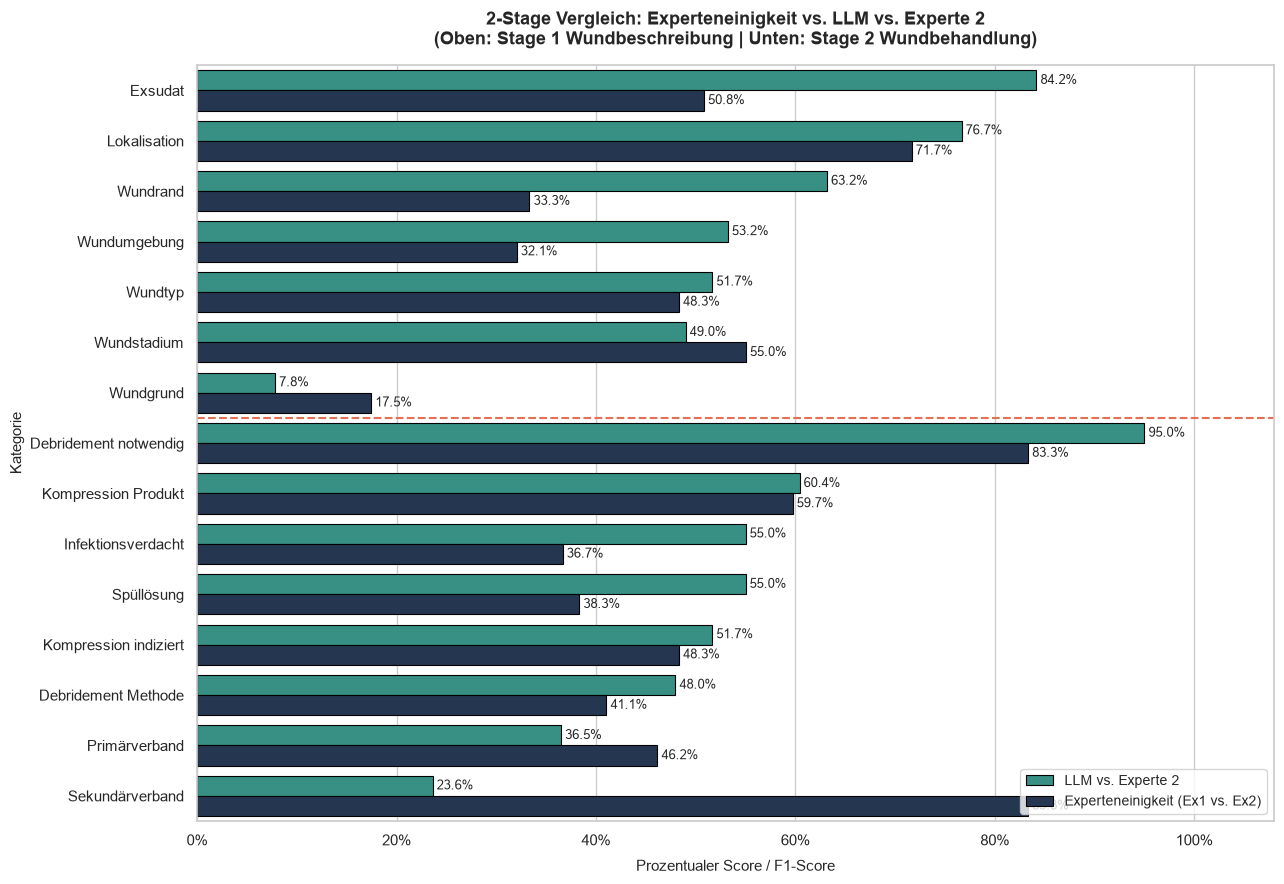

In [4]:
from utils_notebook.LR_utils_notebook.compare_LR import calculate_summary_LR, calculate_experts_summary_LR
from utils_notebook.plot_compare import plot_combined_stage_chart

# 1. Experteneinigkeit (Ex1 vs. Ex2) für normalisierte Daten berechnen
df_experts_norm = calculate_experts_summary_LR(normalised=True)

# 2. Normalisierte LLM-Ergebnisse im Vergleich zu Experte 1 und Experte 2 berechnen
df_summary_norm_exp1 = calculate_summary_LR(1, normalised=True, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)
df_summary_norm_exp2 = calculate_summary_LR(2, normalised=True, path_llm_raw=TWO_STAGE_RAW, path_llm_norm=TWO_STAGE_NORM)

# 3. Plots unterteilt nach Stage 1 (oben) und Stage 2 (unten) anzeigen
plot_combined_stage_chart(df_experts_norm, df_summary_norm_exp1, expert_label="Experte 1")
plot_combined_stage_chart(df_experts_norm, df_summary_norm_exp2, expert_label="Experte 2")
